# Naive TRPO

So TRPO is a iteration over the normal VPG, but instead of implementing the proper objective we implement an objective that behaves like the real objective locally. 

For the loss of the policy network we take:

$L(\theta) = \mathbb{E} [e^{(\log \pi_\theta (a_t|s_t) - \pi_{old} (a_t|s_t))} A_t] =  \mathbb{E} [\frac{ \pi_\theta (a_t|s_t)}{\pi_{old} (a_t|s_t)} A_t] $

But sine the surrogate is an approximation locally we need to preserve locality. For that we use KL divergence to enforce this.

In [1]:
from dataclasses import dataclass
from typing import Dict, List, Sequence

import numpy as np
import torch
import torch.nn as nn
from torch import Tensor
from torch.distributions import Categorical

from pg_env import ActionSample, BatchUpdateAgent, MLPPolicy, MLPValue, RolloutBatch, to_tensor

In [2]:
def discounted_returns_per_episode(
    rewards: Sequence[float],
    dones: Sequence[bool],
    gamma: float,
) -> Tensor:
    """
    Compute Monte Carlo returns on a flattened rollout batch.

    The `dones` tensor indicates episode boundaries so returns reset correctly.
    """
    out: List[float] = [0.0] * len(rewards)
    running_return = 0.0

    for t in reversed(range(len(rewards))):
        if dones[t]:
            running_return = 0.0
        running_return = float(rewards[t]) + gamma * running_return
        out[t] = running_return

    return torch.tensor(out, dtype=torch.float32)

In [3]:
def normalize_tensor(x: Tensor, eps: float = 1e-8) -> Tensor:
    if x.numel() <= 1:
        return x
    return (x - x.mean()) / (x.std() + eps)

In [4]:
def flat_params(model: nn.Module) -> Tensor:
    return torch.cat([p.data.view(-1) for p in model.parameters()])

In [5]:
def set_flat_params(model: nn.Module, flat_vector: Tensor) -> None:
    """
    Overwrite model parameters from a flat vector.
    """
    offset = 0
    for param in model.parameters():
        numel = param.numel()
        param.data.copy_(flat_vector[offset:offset + numel].view_as(param))
        offset += numel

In [6]:
class TRPOLiteAgent(BatchUpdateAgent):
    """
    TRPO-lite:
    - first-order update
    - KL-constrained backtracking line search
    - value regression on returns

    This is not full TRPO, but it captures the trust-region intuition.
    """
    def __init__(
        self,
        obs_dim: int,
        act_dim: int,
        hidden_sizes: Sequence[int] = (64, 64),
        gamma: float = 0.99,
        policy_lr: float = 1e-2,
        value_lr: float = 1e-3,
        value_train_iters: int = 40,
        value_coef: float = 0.5,
        target_kl: float = 0.01,
        backtrack_coeff: float = 0.5,
        backtrack_iters: int = 10,
        device: torch.device | None = None,
    ) -> None:
        self.device = device or torch.device("cpu")
        self.gamma = gamma
        self.value_train_iters = value_train_iters
        self.value_coef = value_coef
        self.target_kl = target_kl
        self.backtrack_coeff = backtrack_coeff
        self.backtrack_iters = backtrack_iters
        self.policy_lr = policy_lr

        self.policy = MLPPolicy(
            obs_dim=obs_dim,
            act_dim=act_dim,
            hidden_sizes=hidden_sizes,
        ).to(self.device)

        self.value_net = MLPValue(
            obs_dim=obs_dim,
            hidden_sizes=hidden_sizes,
        ).to(self.device)

        self.value_optimizer = torch.optim.Adam(self.value_net.parameters(), lr=value_lr)

    # ------------------------------------------------------------------
    # Rollout API
    # ------------------------------------------------------------------
    def _distribution_from_obs_tensor(self, obs_tensor: Tensor) -> Categorical:
        logits = self.policy(obs_tensor)
        return Categorical(logits=logits)

    def sample_action(self, obs: np.ndarray) -> ActionSample:
        obs_tensor = to_tensor(obs, self.device)

        with torch.no_grad():
            dist = self._distribution_from_obs_tensor(obs_tensor)
            action = dist.sample()
            log_prob = dist.log_prob(action)
            value = self.value_net(obs_tensor)

        return ActionSample(
            action=int(action.item()),
            log_prob=log_prob.detach().view(1),
            value=value.detach().view(1),
        )

    def predict_action(self, obs: np.ndarray) -> int:
        with torch.no_grad():
            obs_tensor = to_tensor(obs, self.device)
            logits = self.policy(obs_tensor)
            return int(torch.argmax(logits, dim=-1).item())

    # ------------------------------------------------------------------
    # Batch update
    # ------------------------------------------------------------------
    def update_from_batch(self, batch: RolloutBatch) -> Dict[str, float]:
        obs = torch.as_tensor(
            np.asarray(batch.observations),
            dtype=torch.float32,
            device=self.device,
        )
        actions = torch.as_tensor(batch.actions, dtype=torch.int64, device=self.device)
        rewards = torch.as_tensor(batch.rewards, dtype=torch.float32, device=self.device)
        dones = torch.as_tensor(batch.dones, dtype=torch.bool, device=self.device)

        old_log_probs = torch.cat(
            [lp.view(1) for lp in batch.log_probs if lp is not None]
        ).to(self.device)

        # --------------------------------------------------------------
        # 1) Compute returns and advantages
        # --------------------------------------------------------------
        returns = discounted_returns_per_episode(
            rewards=batch.rewards,
            dones=batch.dones,
            gamma=self.gamma,
        ).to(self.device)

        with torch.no_grad():
            old_values = self.value_net(obs)

        advantages = returns - old_values
        advantages = normalize_tensor(advantages)

        # --------------------------------------------------------------
        # 2) Snapshot old policy distribution
        # --------------------------------------------------------------
        with torch.no_grad():
            old_logits = self.policy(obs)
            old_dist = Categorical(logits=old_logits)
            old_action_log_probs = old_dist.log_prob(actions)
            old_probs = old_dist.probs

        # Safety check: prefer the stored rollout log_probs if available
        # but old_action_log_probs is also valid if policy has not changed
        # since data collection.
        if old_log_probs.shape == old_action_log_probs.shape:
            old_log_probs_for_ratio = old_log_probs
        else:
            old_log_probs_for_ratio = old_action_log_probs

        # --------------------------------------------------------------
        # 3) Surrogate objective under current parameters
        # --------------------------------------------------------------
        def surrogate_and_kl() -> tuple[Tensor, Tensor, Tensor]:
            new_logits = self.policy(obs)
            new_dist = Categorical(logits=new_logits)
            new_log_probs = new_dist.log_prob(actions)

            ratio = torch.exp(new_log_probs - old_log_probs_for_ratio)
            surrogate = torch.mean(ratio * advantages)

            # KL(old || new)
            old_dist_local = Categorical(probs=old_probs)
            kl = torch.mean(torch.distributions.kl.kl_divergence(old_dist_local, new_dist))
            entropy = torch.mean(new_dist.entropy())

            return surrogate, kl, entropy

        surrogate_before, kl_before, entropy_before = surrogate_and_kl()

        # --------------------------------------------------------------
        # 4) Compute gradient ascent direction on surrogate
        # --------------------------------------------------------------
        self.policy.zero_grad()
        # maximize surrogate <=> minimize negative surrogate
        (-surrogate_before).backward()

        grads: List[Tensor] = []
        for param in self.policy.parameters():
            if param.grad is None:
                grads.append(torch.zeros_like(param).view(-1))
            else:
                grads.append(param.grad.view(-1))

        flat_grad = torch.cat(grads)

        old_params = flat_params(self.policy).clone()

        # --------------------------------------------------------------
        # 5) Backtracking line search using KL + surrogate improvement
        # --------------------------------------------------------------
        accepted = False
        final_step_scale = 0.0
        surrogate_after_value = surrogate_before.item()
        kl_after_value = kl_before.item()
        entropy_after_value = entropy_before.item()

        for i in range(self.backtrack_iters):
            step_scale = self.policy_lr * (self.backtrack_coeff ** i)
            candidate_params = old_params - step_scale * flat_grad
            set_flat_params(self.policy, candidate_params)

            with torch.no_grad():
                surrogate_after, kl_after, entropy_after = surrogate_and_kl()

            improves_surrogate = surrogate_after.item() >= surrogate_before.item()
            respects_kl = kl_after.item() <= self.target_kl

            if improves_surrogate and respects_kl:
                accepted = True
                final_step_scale = step_scale
                surrogate_after_value = surrogate_after.item()
                kl_after_value = kl_after.item()
                entropy_after_value = entropy_after.item()
                break

        if not accepted:
            set_flat_params(self.policy, old_params)
            final_step_scale = 0.0
            surrogate_after_value = surrogate_before.item()
            kl_after_value = kl_before.item()
            entropy_after_value = entropy_before.item()

        # --------------------------------------------------------------
        # 6) Fit value network
        # --------------------------------------------------------------
        value_loss_value = 0.0
        for _ in range(self.value_train_iters):
            predicted_values = self.value_net(obs)
            value_loss = torch.mean((predicted_values - returns) ** 2)

            self.value_optimizer.zero_grad()
            value_loss.backward()
            self.value_optimizer.step()

            value_loss_value = float(value_loss.item())

        # --------------------------------------------------------------
        # 7) Logging
        # --------------------------------------------------------------
        approx_ratio_mean = 0.0
        with torch.no_grad():
            new_logits = self.policy(obs)
            new_dist = Categorical(logits=new_logits)
            new_log_probs = new_dist.log_prob(actions)
            ratio = torch.exp(new_log_probs - old_log_probs_for_ratio)
            approx_ratio_mean = float(ratio.mean().item())

        return {
            "policy_loss": float(-surrogate_after_value),
            "value_loss": value_loss_value,
            "surrogate_before": float(surrogate_before.item()),
            "surrogate_after": float(surrogate_after_value),
            "approx_kl": float(kl_after_value),
            "entropy": float(entropy_after_value),
            "mean_ratio": approx_ratio_mean,
            "accepted_step": 1.0 if accepted else 0.0,
            "step_scale": float(final_step_scale),
            "batch_mean_return": float(batch.mean_episode_return),
        }

In [7]:
def build_trpo_lite_agent_from_env(
    env_fn,
    hidden_sizes=(64, 64),
    gamma: float = 0.99,
    policy_lr: float = 1e-2,
    value_lr: float = 1e-3,
    target_kl: float = 0.01,
    backtrack_coeff: float = 0.5,
    backtrack_iters: int = 10,
    device: torch.device | None = None,
) -> TRPOLiteAgent:
    env = env_fn()


    obs_dim = int(np.prod(env.observation_space.shape))
    act_dim = int(env.action_space.n)

    env.close()

    return TRPOLiteAgent(
        obs_dim=obs_dim,
        act_dim=act_dim,
        hidden_sizes=hidden_sizes,
        gamma=gamma,
        policy_lr=policy_lr,
        value_lr=value_lr,
        target_kl=target_kl,
        device=device,
    )

In [8]:
from pg_env import (
    set_seed,
    make_cartpole_env,
    train_on_policy_batches,
    plot_training_history,
    run_demo_episode
)

[iter    1] batch_mean_return=  21.81 | steps= 2050 | episodes= 94 | eval_mean_return=   9.60 | policy_loss=  -0.0013
[iter    5] batch_mean_return=  22.55 | steps= 2052 | episodes= 91 | eval_mean_return=  21.00 | policy_loss=  -0.0017
[iter   10] batch_mean_return=  26.70 | steps= 2056 | episodes= 77 | eval_mean_return=  35.00 | policy_loss=  -0.0023
[iter   15] batch_mean_return=  25.95 | steps= 2076 | episodes= 80 | eval_mean_return=  99.00 | policy_loss=  -0.0038
[iter   20] batch_mean_return=  37.02 | steps= 2073 | episodes= 56 | eval_mean_return= 132.20 | policy_loss=  -0.0047
[iter   25] batch_mean_return=  48.21 | steps= 2073 | episodes= 43 | eval_mean_return= 237.20 | policy_loss=  -0.0019
[iter   30] batch_mean_return=  59.19 | steps= 2131 | episodes= 36 | eval_mean_return= 286.40 | policy_loss=  -0.0021
[iter   35] batch_mean_return=  66.25 | steps= 2120 | episodes= 32 | eval_mean_return= 430.60 | policy_loss=  -0.0098
[iter   40] batch_mean_return=  94.36 | steps= 2076 | ep

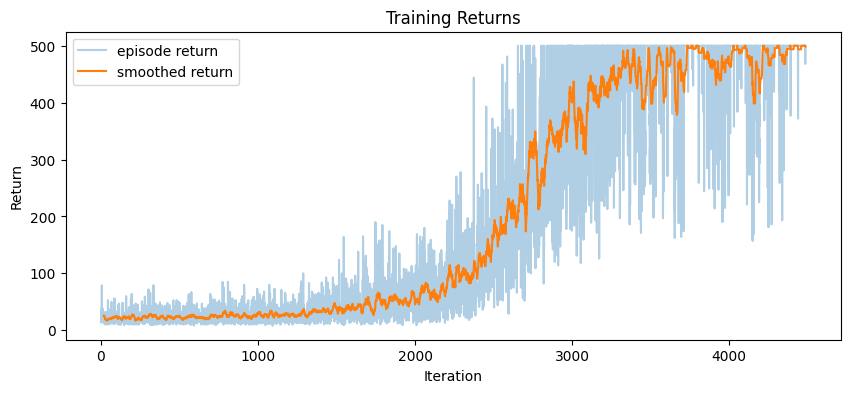

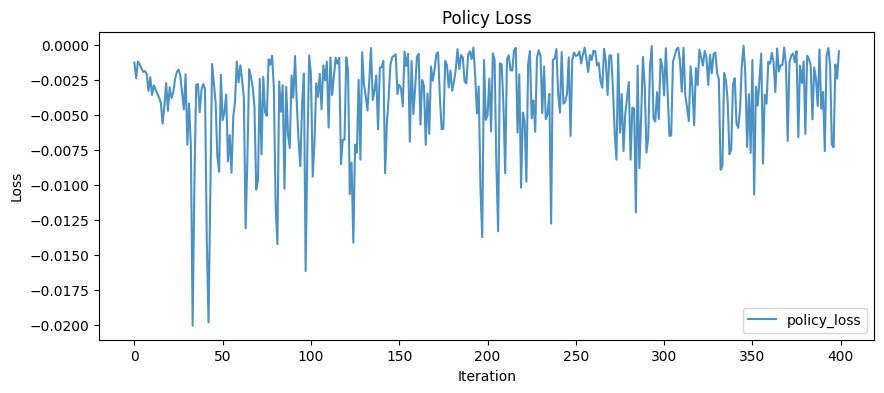

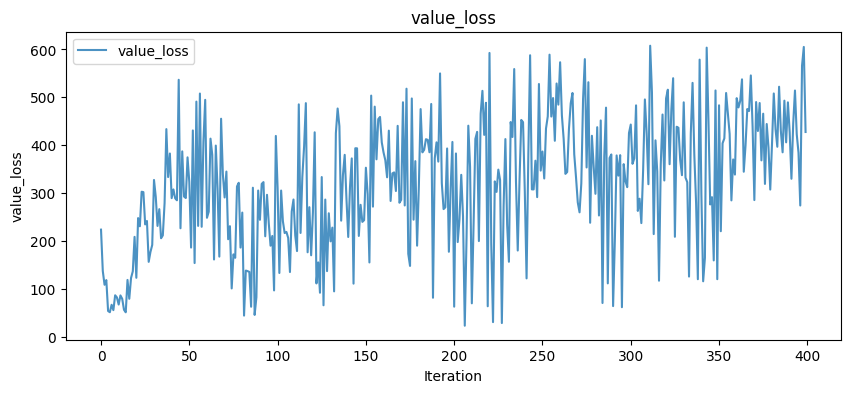

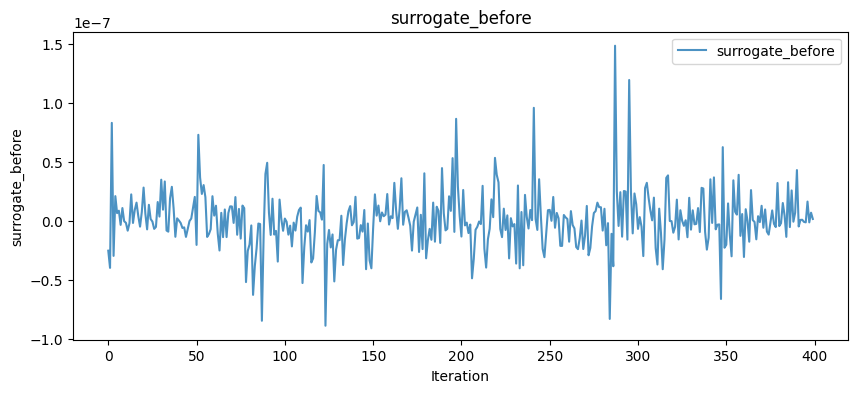

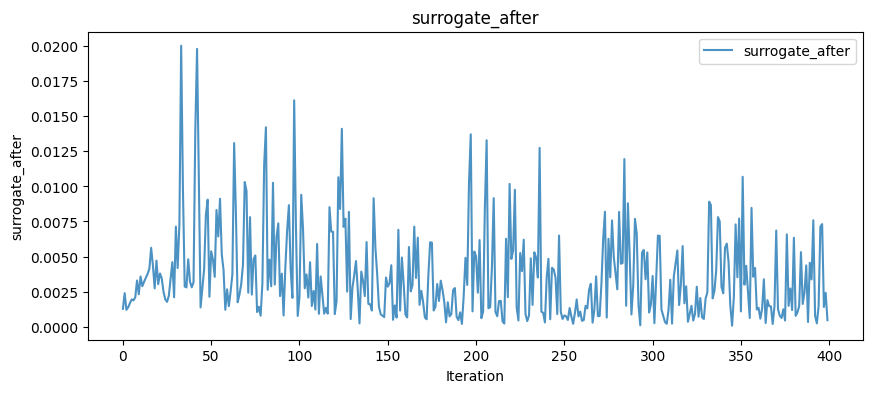

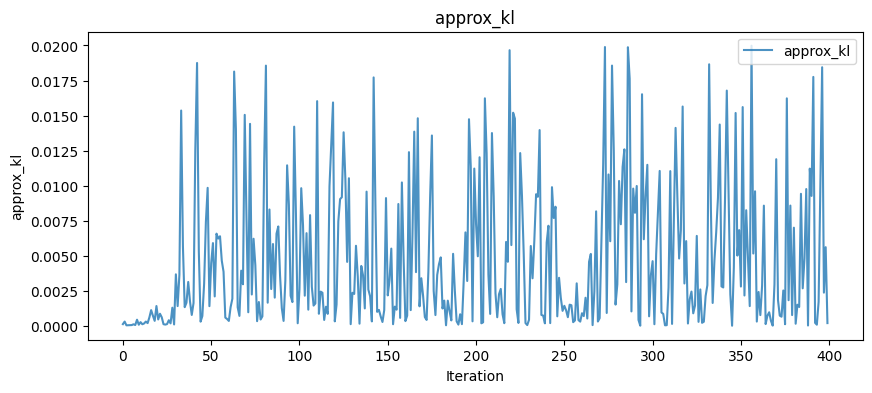

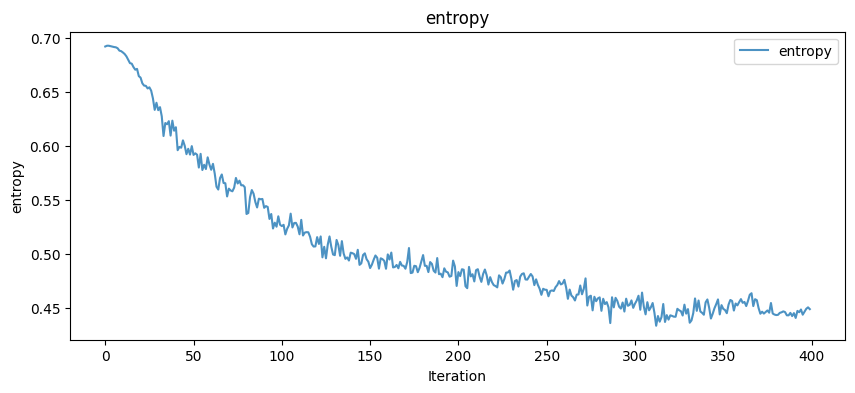

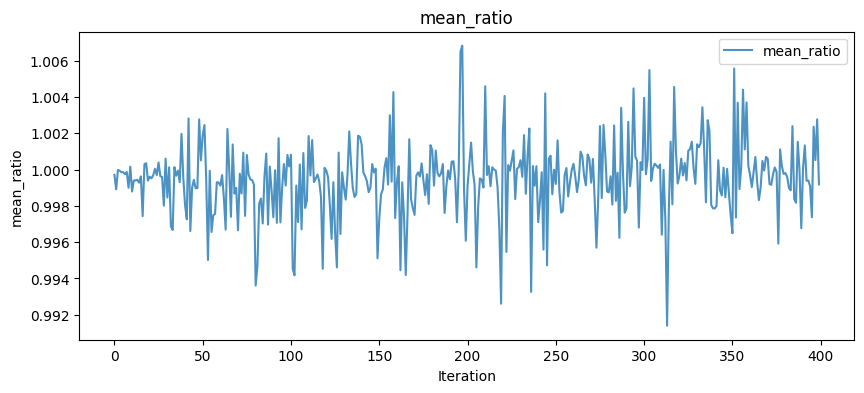

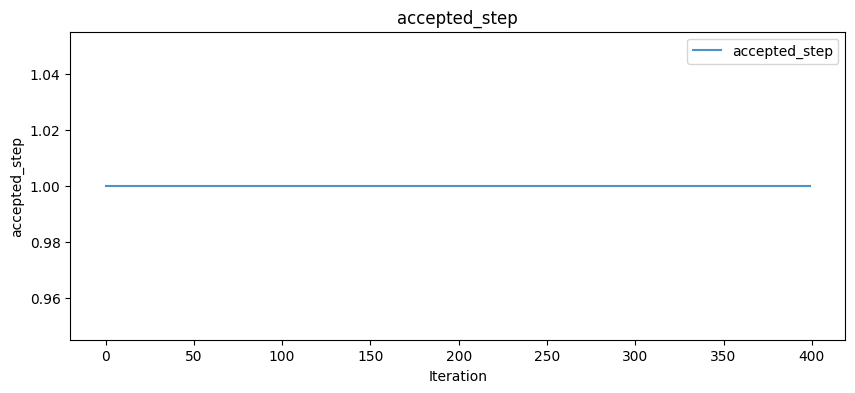

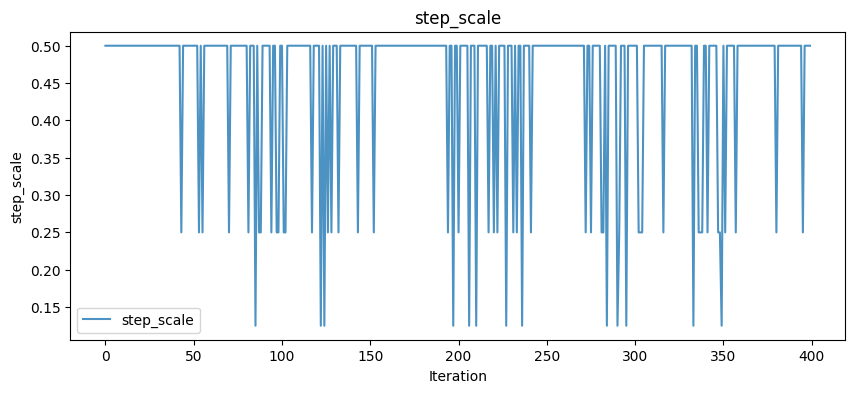

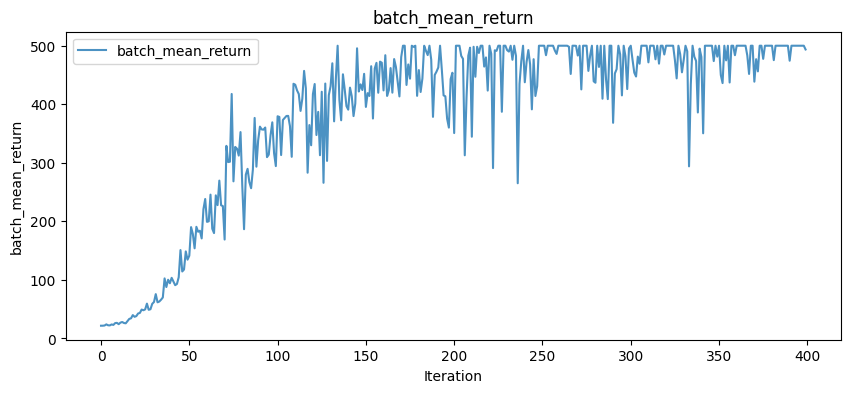

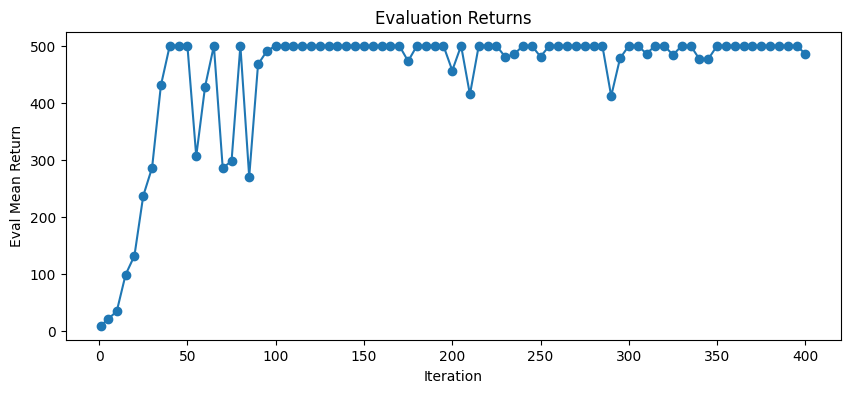

In [9]:
set_seed(42)

env_fn = lambda: make_cartpole_env(render_mode=None)

agent = build_trpo_lite_agent_from_env(
    env_fn=env_fn,
    hidden_sizes=(64, 64),
    gamma=0.99,
    policy_lr=0.5,
    value_lr=1e-3,
    target_kl=0.02,
    backtrack_coeff = 0.5,
    backtrack_iters = 12
)

history = train_on_policy_batches(
    env_fn=env_fn,
    agent=agent,
    num_iterations=400,
    batch_size=2048,
    eval_every=5,
    eval_episodes=5,
    verbose=True,
)

plot_training_history(history)

In [10]:
visual_env = lambda: make_cartpole_env(render_mode="human")

run_demo_episode(visual_env, agent, greedy=True)


/mnt/hd/Repos/ds_be_like/.venv/lib/python3.10/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


Demo return: 500.00


500.0